# Prepare Environment

In [1]:
# Check for local CSV; if missing, download from Firebase using pyasebase/pyrebase
import os
import pandas as pd
from pybaseball import pitching_stats
import numpy as np

csv_path = "./data/pitching_stats.csv"

if os.path.exists(csv_path):
    print(f"Found {csv_path}, reading into DataFrame.")
    data = pd.read_csv(csv_path)
else:
    print(f"{csv_path} not found — attempting to download using pybaseball.")
    qual = 10
    start_season = 2015
    end_season = 2025
    data = pitching_stats(start_season=start_season, end_season=end_season, qual=qual)
    # data.to_csv('./data/pitching_stats.csv', index=False)

Found ./data/pitching_stats.csv, reading into DataFrame.


# Prepare Training Data

In [2]:
data.groupby("Season").sum()['CSW%']

Season
2015    159.553
2016    160.208
2017    164.674
2018    168.886
2019    177.276
2020    138.957
2021    185.240
2022    178.045
2023    181.105
2024    179.744
2025    179.084
Name: CSW%, dtype: float64

In [3]:
# Process data for 3D tensor - organized by player-season combination
import torch
import numpy as np
import pandas as pd

# Select relevant columns
features = [
    'Age',
    'ERA',
    'G',
    'GS',
    'IP',
    'TBF',
    'HR',
    'BB',
    'IBB',
    'HBP',
    'SO',
    'GB',
    'GB%',
    'FB',
    'FB%',
    'LD',
    'LD%',
    'IFFB',
    'Pitches',
    'BABIP',
    'WHIP',
    'FIP',
    'xFIP',
    'SIERA',
    'CStr%',
    'CSW%',
    'Barrels',
    'Barrel%',
    'HardHit',
    'HardHit%',
]

target = 'WAR'

# Qualification parameter: minimum IP in target season to include in training set
min_qual_ip = 50  # Set to > 0 to filter by innings pitched (e.g., 50 for minimum 50 IP)

# Ensure data has the necessary columns
required_cols = features + [target, 'IDfg', 'Season']
data_processed = data.reindex(columns=[c for c in data.columns if c in required_cols]).fillna(0)

# Group by player
grouped = data_processed.groupby('IDfg')

sequences = []
targets = []
metadata = []  # Track player_id, season for each row

nlookback = 5

for player_id, player_data in grouped:
    # Sort by season
    player_data = player_data.sort_values('Season').reset_index(drop=True)

    # Need at least 2 years: nlookback periods + 1 for target
    if len(player_data) >= 2:
        for i in range(len(player_data) - 1):
            # Check qualification: target season must have at least min_qual_ip innings pitched
            target_ip = player_data.iloc[i + 1]['IP']
            if target_ip < min_qual_ip:
                continue  # Skip this record if it doesn't meet qualification
            
            # lookback, padded with 0s if less
            seq_length = min(nlookback, i + 1)
            seq_data = np.zeros((nlookback, len(features)))

            # Select the rows for this sequence
            seq_rows = player_data.iloc[i - seq_length + 1:i + 1]

            # Reindex columns to `features` to ensure consistent order
            vals = seq_rows.reindex(columns=features).fillna(0).values
            if vals.ndim == 1:
                vals = vals.reshape(1, -1)

            # Safety: if column count mismatches, trim or pad
            if vals.shape[1] != len(features):
                if vals.shape[1] > len(features):
                    vals = vals[:, :len(features)]
                else:
                    pad = np.zeros((vals.shape[0], len(features) - vals.shape[1]))
                    vals = np.hstack([vals, pad])

            # Place at the end of seq_data (right-align)
            seq_data[nlookback - seq_length:] = vals

            # Target: WAR and IP of next year
            target_season = player_data.iloc[i + 1]['Season']
            target_war = player_data.iloc[i + 1][target]

            sequences.append(seq_data)
            targets.append(target_war)
            metadata.append({
                'player_id': player_id,
                'current_season': int(player_data.iloc[i]['Season']),
                'target_season': int(target_season),
                'target_ip': float(target_ip),
            })

# Convert to numpy arrays and torch tensors
sequences = np.array(sequences)  # Shape: (num_sequences, nlookback, len(features))
targets_war = np.array(targets)      # Shape: (num_sequences,) - WAR targets
targets_ip = np.array([m['target_ip'] for m in metadata])  # Shape: (num_sequences,) - IP targets

# Extract FIP from metadata (next year's FIP is the FIP from the target row)
targets_fip = []
for player_id, player_data in grouped:
    player_data = player_data.sort_values('Season').reset_index(drop=True)
    if len(player_data) >= 2:
        for i in range(len(player_data) - 1):
            target_ip = player_data.iloc[i + 1]['IP']
            if target_ip < min_qual_ip:
                continue
            target_fip = player_data.iloc[i + 1]['FIP']
            targets_fip.append(target_fip)

targets_fip = np.array(targets_fip)

X = torch.tensor(sequences, dtype=torch.float32)
y_war = torch.tensor(targets_war, dtype=torch.float32)
y_ip = torch.tensor(targets_ip, dtype=torch.float32)
y_fip = torch.tensor(targets_fip, dtype=torch.float32)

# Create metadata DataFrame indexed by player_id and target_season
metadata_df = pd.DataFrame(metadata)
metadata_df = metadata_df.set_index(['player_id', 'target_season'])

print(f"Tensor shape: {X.shape}")
print(f"WAR target shape: {y_war.shape}")
print(f"IP target shape: {y_ip.shape}")
print(f"FIP target shape: {y_fip.shape}")
print(f"Metadata rows: {len(metadata_df)}")
print(f"Qualification filter: min_qual_ip = {min_qual_ip}")
print(f"\nFirst few metadata entries:")
print(metadata_df.head())
print(f"\nSample sequence for entry 0:\n{X[0]}")
print(f"Corresponding WAR target: {y_war[0]:.4f}, IP target: {y_ip[0]:.2f}, FIP target: {y_fip[0]:.2f}")


Tensor shape: torch.Size([2804, 5, 30])
WAR target shape: torch.Size([2804])
IP target shape: torch.Size([2804])
FIP target shape: torch.Size([2804])
Metadata rows: 2804
Qualification filter: min_qual_ip = 50

First few metadata entries:
                         current_season  target_ip
player_id target_season                           
18        2016                     2015       53.2
375       2016                     2015      191.2
          2017                     2016      143.0
          2018                     2017      146.1
404       2016                     2015      179.2

Sample sequence for entry 0:
tensor([[0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
         0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
         0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
         0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
         0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000

# Prepare Prediction Data

In [4]:
# Create prediction set for 2025 season
pred_season = 2025

pred_sequences = []
pred_metadata = []

for player_id, player_data in grouped:
    # Sort by season
    player_data = player_data.sort_values('Season').reset_index(drop=True)
    
    # Check if player has data for pred_season
    if pred_season in player_data['Season'].values:
        # Find the index of pred_season
        pred_idx = player_data[player_data['Season'] == pred_season].index[0]
        
        # Build sequence using data up to pred_season
        seq_length = min(nlookback, pred_idx + 1)
        seq_data = np.zeros((nlookback, len(features)))
        
        # Select rows from pred_season going back nlookback periods
        seq_rows = player_data.iloc[pred_idx - seq_length + 1:pred_idx + 1]
        
        # Reindex to ensure consistent column order
        vals = seq_rows.reindex(columns=features).fillna(0).values
        if vals.ndim == 1:
            vals = vals.reshape(1, -1)
        
        # Handle column mismatches
        if vals.shape[1] != len(features):
            if vals.shape[1] > len(features):
                vals = vals[:, :len(features)]
            else:
                pad = np.zeros((vals.shape[0], len(features) - vals.shape[1]))
                vals = np.hstack([vals, pad])
        
        # Place at end of seq_data (right-align)
        seq_data[nlookback - seq_length:] = vals
        
        pred_sequences.append(seq_data)
        pred_metadata.append({
            'player_id': player_id,
            'prediction_season': pred_season,
        })

# Convert to torch tensors
X_pred = torch.tensor(np.array(pred_sequences), dtype=torch.float32)
pred_metadata_df = pd.DataFrame(pred_metadata).set_index('player_id')

print(f"Prediction set size: {X_pred.shape}")
print(f"Number of players with {pred_season} data: {len(pred_metadata_df)}")
print(f"\nFirst few prediction metadata entries:")
print(pred_metadata_df.head())


Prediction set size: torch.Size([657, 5, 30])
Number of players with 2025 data: 657

First few prediction metadata entries:
           prediction_season
player_id                   
2036                    2025
3096                    2025
3137                    2025
3237                    2025
3548                    2025


# Define Model using Transformer

In [8]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import numpy as np

class MultiVariateTransformer(nn.Module):
    def __init__(self, input_dim, d_model=64, nhead=4, num_layers=2, dim_feedforward=128, dropout=0.1, seq_len=5):
        """
        Transformer model for predicting next-year IP, ERA, and WAR from historical pitcher statistics.
        WAR prediction depends on both IP and ERA predictions plus transformer features.
        
        Args:
            input_dim: Number of features (pitcher statistics)
            d_model: Dimension of the transformer embeddings
            nhead: Number of attention heads
            num_layers: Number of transformer encoder layers
            dim_feedforward: Dimension of feedforward network
            dropout: Dropout rate
            seq_len: Length of input sequences (lookback window)
        """
        super(MultiVariateTransformer, self).__init__()
        
        self.input_dim = input_dim
        self.d_model = d_model
        self.seq_len = seq_len
        
        # Linear projection from input features to d_model
        self.input_projection = nn.Linear(input_dim, d_model)
        
        # Positional encoding
        self.positional_encoding = nn.Parameter(torch.randn(1, seq_len, d_model))
        
        # Transformer encoder
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=dim_feedforward,
            dropout=dropout,
            batch_first=True
        )
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        
        # IP prediction head (independent)
        self.ip_head = nn.Sequential(
            nn.Linear(d_model * seq_len, 256),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, 1)
        )
        
        # FIP prediction head (independent)
        self.fip_head = nn.Sequential(
            nn.Linear(d_model * seq_len, 256),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, 1)
        )
        
        # WAR prediction head (depends on IP and FIP)
        self.war_head = nn.Sequential(
            nn.Linear(d_model * seq_len + 2, 256),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, 1)
        )
    
    def forward(self, x):
        """Forward pass through transformer model.
        
        Returns:
            ip_pred: Predicted next-year IP (batch_size,)
            fip_pred: Predicted next-year FIP (batch_size,)
            war_pred: Predicted next-year WAR (batch_size,)
        """
        # Transformer encoding
        x_encoded = self.input_projection(x)
        x_encoded = x_encoded + self.positional_encoding
        x_encoded = self.transformer_encoder(x_encoded)
        x_flat = x_encoded.reshape(x_encoded.size(0), -1)
        
        # Predict IP and FIP independently
        ip_pred = self.ip_head(x_flat).squeeze(-1)
        fip_pred = self.fip_head(x_flat).squeeze(-1)
        
        # Predict WAR using transformer output and both IP and FIP predictions
        war_input = torch.cat([x_flat, ip_pred.unsqueeze(-1), fip_pred.unsqueeze(-1)], dim=1)
        war_pred = self.war_head(war_input).squeeze(-1)
        
        return ip_pred, fip_pred, war_pred


def prepare_data(X, y_war, y_ip, y_fip, test_size=0.2, batch_size=32, store_scaler_path='./scaler.pkl'):
    """
    Prepare data for training: normalize, split, and create DataLoaders.
    Stores the scaler for later use on prediction data.
    
    Args:
        X: Tensor of shape (num_sequences, seq_len, num_features)
        y_war: Tensor of shape (num_sequences,) - WAR targets
        y_ip: Tensor of shape (num_sequences,) - IP targets
        y_fip: Tensor of shape (num_sequences,) - FIP targets
        test_size: Proportion of data for validation
        batch_size: Batch size for DataLoaders
        store_scaler_path: Path to save the fitted scaler
    
    Returns:
        train_loader, val_loader, scaler, y_war_mean, y_war_std, y_ip_mean, y_ip_std, y_fip_mean, y_fip_std, device
    """
    import pickle
    
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    
    # Normalize features across all sequences
    X_np = X.cpu().numpy()  # (num_sequences, seq_len, num_features)
    num_sequences, seq_len, num_features = X_np.shape
    
    # Reshape for scaling: (num_sequences * seq_len, num_features)
    X_reshaped = X_np.reshape(-1, num_features)
    
    # Fit scaler on training data
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_reshaped)
    
    # Save scaler
    with open(store_scaler_path, 'wb') as f:
        pickle.dump(scaler, f)
    print(f"Scaler saved to {store_scaler_path}")
    
    # Reshape back to original dimensions
    X_scaled = X_scaled.reshape(num_sequences, seq_len, num_features)
    X_scaled = torch.tensor(X_scaled, dtype=torch.float32)
    
    # Normalize WAR targets
    y_war_np = y_war.cpu().numpy() if isinstance(y_war, torch.Tensor) else y_war
    y_war_mean = np.mean(y_war_np)
    y_war_std = np.std(y_war_np)
    y_war_normalized = (y_war_np - y_war_mean) / (y_war_std + 1e-8)
    y_war_normalized = torch.tensor(y_war_normalized, dtype=torch.float32)
    
    # Normalize IP targets
    y_ip_np = y_ip.cpu().numpy() if isinstance(y_ip, torch.Tensor) else y_ip
    y_ip_mean = np.mean(y_ip_np)
    y_ip_std = np.std(y_ip_np)
    y_ip_normalized = (y_ip_np - y_ip_mean) / (y_ip_std + 1e-8)
    y_ip_normalized = torch.tensor(y_ip_normalized, dtype=torch.float32)
    
    # Normalize FIP targets
    y_fip_np = y_fip.cpu().numpy() if isinstance(y_fip, torch.Tensor) else y_fip
    y_fip_mean = np.mean(y_fip_np)
    y_fip_std = np.std(y_fip_np)
    y_fip_normalized = (y_fip_np - y_fip_mean) / (y_fip_std + 1e-8)
    y_fip_normalized = torch.tensor(y_fip_normalized, dtype=torch.float32)
    
    # Train-validation split
    X_train, X_val, y_war_train, y_war_val, y_ip_train, y_ip_val, y_fip_train, y_fip_val = train_test_split(
        X_scaled, y_war_normalized, y_ip_normalized, y_fip_normalized, test_size=test_size, random_state=42
    )
    
    # Create datasets with all targets
    train_dataset = TensorDataset(
        X_train.to(device), 
        y_war_train.to(device),
        y_ip_train.to(device),
        y_fip_train.to(device)
    )
    val_dataset = TensorDataset(
        X_val.to(device), 
        y_war_val.to(device),
        y_ip_val.to(device),
        y_fip_val.to(device)
    )
    
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
    
    return train_loader, val_loader, scaler, torch.tensor(y_war_mean), torch.tensor(y_war_std), torch.tensor(y_ip_mean), torch.tensor(y_ip_std), torch.tensor(y_fip_mean), torch.tensor(y_fip_std), device


def train_model(model, train_loader, val_loader, num_epochs=100, learning_rate=1e-3, 
                patience=15, device='cpu', ip_weight=0.2, fip_weight=0.2, war_weight=0.6):
    """
    Train transformer model with three outputs (IP, FIP, WAR) with early stopping and learning rate scheduler.
    WAR loss is weighted highest since WAR depends on both IP and FIP.
    
    Args:
        model: MultiVariateTransformer model
        train_loader: DataLoader for training data
        val_loader: DataLoader for validation data
        num_epochs: Maximum number of epochs
        learning_rate: Initial learning rate
        patience: Number of epochs without improvement before early stopping
        device: Device to train on
        ip_weight: Weight for IP loss
        fip_weight: Weight for FIP loss
        war_weight: Weight for WAR loss
    
    Returns:
        model, train_losses, val_losses, best_epoch
    """
    model = model.to(device)
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    
    # Learning rate scheduler
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5, patience=5
    )
    
    train_losses = []
    val_losses = []
    best_val_loss = float('inf')
    patience_counter = 0
    best_epoch = 0
    
    for epoch in range(num_epochs):
        # Training phase
        model.train()
        train_loss = 0.0
        for X_batch, y_war_batch, y_ip_batch, y_fip_batch in train_loader:
            optimizer.zero_grad()
            ip_pred, fip_pred, war_pred = model(X_batch)
            
            # Combined loss: weighted sum of IP, FIP, and WAR losses
            ip_loss = criterion(ip_pred, y_ip_batch)
            fip_loss = criterion(fip_pred, y_fip_batch)
            war_loss = criterion(war_pred, y_war_batch)
            loss = ip_weight * ip_loss + fip_weight * fip_loss + war_weight * war_loss
            
            loss.backward()
            optimizer.step()
            train_loss += loss.item()
        
        train_loss /= len(train_loader)
        train_losses.append(train_loss)
        
        # Validation phase
        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for X_batch, y_war_batch, y_ip_batch, y_fip_batch in val_loader:
                ip_pred, fip_pred, war_pred = model(X_batch)
                
                ip_loss = criterion(ip_pred, y_ip_batch)
                fip_loss = criterion(fip_pred, y_fip_batch)
                war_loss = criterion(war_pred, y_war_batch)
                loss = ip_weight * ip_loss + fip_weight * fip_loss + war_weight * war_loss
                
                val_loss += loss.item()
        
        val_loss /= len(val_loader)
        val_losses.append(val_loss)
        
        # Learning rate scheduling
        scheduler.step(val_loss)
        
        # Early stopping
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            patience_counter = 0
            best_epoch = epoch
            torch.save(model.state_dict(), './results/v1/best_model.pt')
        else:
            patience_counter += 1
        
        if (epoch + 1) % 10 == 0:
            print(f"Epoch {epoch+1}/{num_epochs}, Train Loss: {train_loss:.6f}, Val Loss: {val_loss:.6f}")
        
        if patience_counter >= patience:
            print(f"Early stopping at epoch {epoch+1}")
            model.load_state_dict(torch.load('./results/v1/best_model.pt'))
            break
    
    return model, train_losses, val_losses, best_epoch


def plot_losses(train_losses, val_losses, title='Training and Validation Losses'):
    """
    Plot training and validation losses.
    
    Args:
        train_losses: List of training losses
        val_losses: List of validation losses
        title: Plot title
    """
    plt.figure(figsize=(10, 6))
    plt.plot(train_losses, label='Train Loss', marker='o', markersize=3)
    plt.plot(val_losses, label='Validation Loss', marker='s', markersize=3)
    plt.xlabel('Epoch')
    plt.ylabel('Loss (MSE)')
    plt.title(title)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

# Initialize model
device = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')
model = MultiVariateTransformer(
    input_dim=len(features),
    d_model=64,
    nhead=4,
    num_layers=2,
    dim_feedforward=128,
    dropout=0.1,
    seq_len=nlookback
).to(device)

print(f"Model initialized on device: {device}")
print(f"Total parameters: {sum(p.numel() for p in model.parameters()):,}")

Model initialized on device: mps
Total parameters: 415,363


In [9]:
print(model)

MultiVariateTransformer(
  (input_projection): Linear(in_features=30, out_features=64, bias=True)
  (transformer_encoder): TransformerEncoder(
    (layers): ModuleList(
      (0-1): 2 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=64, out_features=64, bias=True)
        )
        (linear1): Linear(in_features=64, out_features=128, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=128, out_features=64, bias=True)
        (norm1): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.1, inplace=False)
        (dropout2): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (ip_head): Sequential(
    (0): Linear(in_features=320, out_features=256, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.1, inplace=False)
    (3): Linear(in_features=256, out_features=128

Scaler saved to ./scaler.pkl
WAR - Mean: 1.3077, Std: 1.3699
IP - Mean: 100.85, Std: 47.85
FIP - Mean: 4.03, Std: 0.92
Epoch 10/100, Train Loss: 0.636119, Val Loss: 0.719530
Epoch 20/100, Train Loss: 0.547233, Val Loss: 0.717879
Early stopping at epoch 27
Best epoch: 7


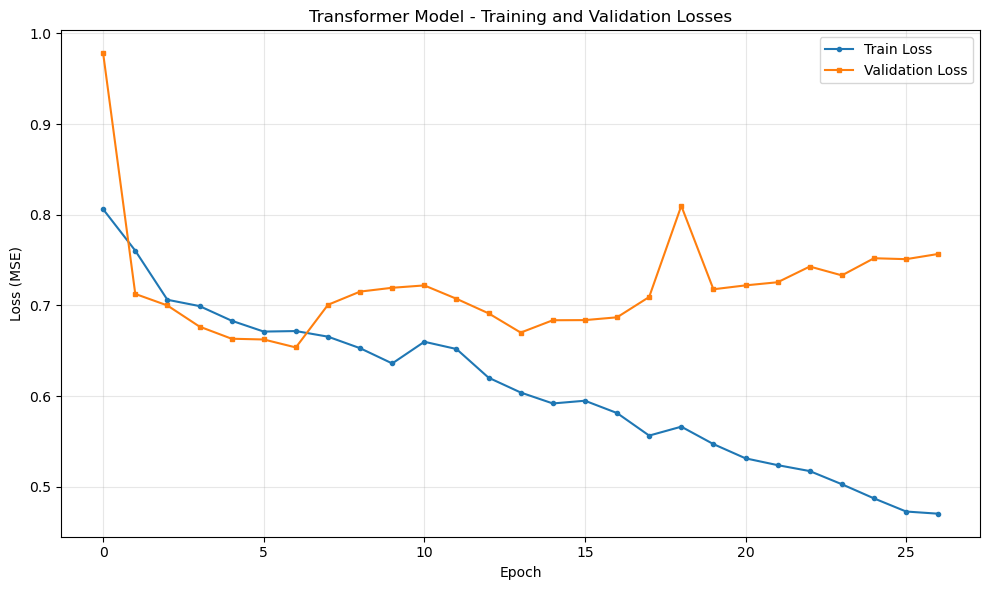


Validation Metrics (normalized):
  IP - MSE: 0.503202, RMSE: 0.709367, R²: 0.5208
  FIP - MSE: 0.742095, RMSE: 0.861449, R²: 0.2135
  WAR - MSE: 0.662520, RMSE: 0.813953, R²: 0.4138

Validation Metrics (denormalized):
  IP - MAE: 24.35 innings
  FIP - MAE: 0.625
  WAR - MAE: 0.8492


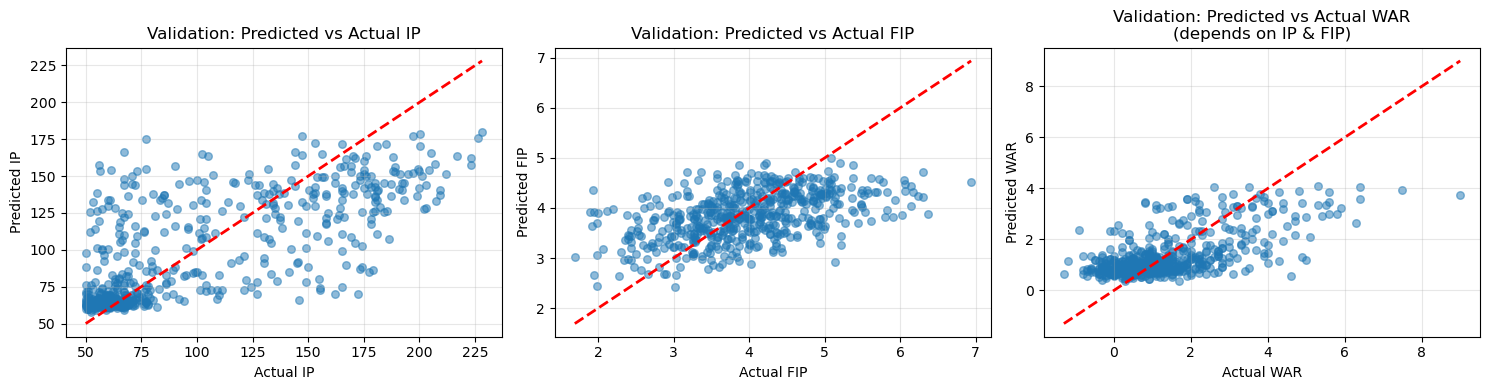


Model and scaler saved for predictions


In [10]:
# Prepare data and save scaler
train_loader, val_loader, scaler, y_war_mean, y_war_std, y_ip_mean, y_ip_std, y_fip_mean, y_fip_std, device = prepare_data(
    X, y_war, y_ip, y_fip, batch_size=32
)

print(f"WAR - Mean: {y_war_mean.item():.4f}, Std: {y_war_std.item():.4f}")
print(f"IP - Mean: {y_ip_mean.item():.2f}, Std: {y_ip_std.item():.2f}")
print(f"FIP - Mean: {y_fip_mean.item():.2f}, Std: {y_fip_std.item():.2f}")

# Train model with early stopping
model, train_losses, val_losses, best_epoch = train_model(
    model, train_loader, val_loader, 
    num_epochs=100, 
    learning_rate=1e-3, 
    patience=20, 
    device=device,
    ip_weight=0.2,    # Lower weight for IP
    fip_weight=0.2,   # Lower weight for FIP
    war_weight=0.6    # Higher weight for WAR (which depends on both IP and FIP)
)

print(f"Best epoch: {best_epoch + 1}")

# Plot losses
plot_losses(train_losses, val_losses, title='Transformer Model - Training and Validation Losses')

# Make predictions on validation set
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

model.eval()
ip_predictions = []
fip_predictions = []
war_predictions = []
ip_actuals = []
fip_actuals = []
war_actuals = []

with torch.no_grad():
    for inputs, targets_war, targets_ip, targets_fip in val_loader:
        ip_pred, fip_pred, war_pred = model(inputs)
        ip_predictions.extend(ip_pred.cpu().numpy().flatten())
        fip_predictions.extend(fip_pred.cpu().numpy().flatten())
        war_predictions.extend(war_pred.cpu().numpy().flatten())
        ip_actuals.extend(targets_ip.cpu().numpy())
        fip_actuals.extend(targets_fip.cpu().numpy())
        war_actuals.extend(targets_war.cpu().numpy())

# Denormalize predictions and actuals for interpretability
ip_predictions_denorm = np.array(ip_predictions) * y_ip_std.item() + y_ip_mean.item()
ip_actuals_denorm = np.array(ip_actuals) * y_ip_std.item() + y_ip_mean.item()
fip_predictions_denorm = np.array(fip_predictions) * y_fip_std.item() + y_fip_mean.item()
fip_actuals_denorm = np.array(fip_actuals) * y_fip_std.item() + y_fip_mean.item()
war_predictions_denorm = np.array(war_predictions) * y_war_std.item() + y_war_mean.item()
war_actuals_denorm = np.array(war_actuals) * y_war_std.item() + y_war_mean.item()

# Calculate metrics
ip_mse = mean_squared_error(ip_actuals, ip_predictions)
ip_rmse = np.sqrt(ip_mse)
ip_mae = mean_absolute_error(ip_actuals_denorm, ip_predictions_denorm)
ip_r2 = r2_score(ip_actuals, ip_predictions)

fip_mse = mean_squared_error(fip_actuals, fip_predictions)
fip_rmse = np.sqrt(fip_mse)
fip_mae = mean_absolute_error(fip_actuals_denorm, fip_predictions_denorm)
fip_r2 = r2_score(fip_actuals, fip_predictions)

war_mse = mean_squared_error(war_actuals, war_predictions)
war_rmse = np.sqrt(war_mse)
war_mae = mean_absolute_error(war_actuals_denorm, war_predictions_denorm)
war_r2 = r2_score(war_actuals, war_predictions)

print(f"\nValidation Metrics (normalized):")
print(f"  IP - MSE: {ip_mse:.6f}, RMSE: {ip_rmse:.6f}, R²: {ip_r2:.4f}")
print(f"  FIP - MSE: {fip_mse:.6f}, RMSE: {fip_rmse:.6f}, R²: {fip_r2:.4f}")
print(f"  WAR - MSE: {war_mse:.6f}, RMSE: {war_rmse:.6f}, R²: {war_r2:.4f}")
print(f"\nValidation Metrics (denormalized):")
print(f"  IP - MAE: {ip_mae:.2f} innings")
print(f"  FIP - MAE: {fip_mae:.3f}")
print(f"  WAR - MAE: {war_mae:.4f}")

# Plot predictions vs actuals (3 subplots)
plt.figure(figsize=(15, 4))

plt.subplot(1, 3, 1)
plt.scatter(ip_actuals_denorm, ip_predictions_denorm, alpha=0.5, s=30)
plt.plot([min(ip_actuals_denorm), max(ip_actuals_denorm)], 
         [min(ip_actuals_denorm), max(ip_actuals_denorm)], 'r--', lw=2)
plt.xlabel('Actual IP')
plt.ylabel('Predicted IP')
plt.title('Validation: Predicted vs Actual IP')
plt.grid(True, alpha=0.3)

plt.subplot(1, 3, 2)
plt.scatter(fip_actuals_denorm, fip_predictions_denorm, alpha=0.5, s=30)
plt.plot([min(fip_actuals_denorm), max(fip_actuals_denorm)], 
         [min(fip_actuals_denorm), max(fip_actuals_denorm)], 'r--', lw=2)
plt.xlabel('Actual FIP')
plt.ylabel('Predicted FIP')
plt.title('Validation: Predicted vs Actual FIP')
plt.grid(True, alpha=0.3)

plt.subplot(1, 3, 3)
plt.scatter(war_actuals_denorm, war_predictions_denorm, alpha=0.5, s=30)
plt.plot([min(war_actuals_denorm), max(war_actuals_denorm)], 
         [min(war_actuals_denorm), max(war_actuals_denorm)], 'r--', lw=2)
plt.xlabel('Actual WAR')
plt.ylabel('Predicted WAR')
plt.title('Validation: Predicted vs Actual WAR\n(depends on IP & FIP)')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nModel and scaler saved for predictions")

PREDICTING 2026 WAR FOR 2025 SEASON DATA

2026 Predictions for 657 players

Top 20 predicted WAR leaders for 2026:
     player_id  predicted_ip_2026  predicted_fip_2026  predicted_war_2026
305      20778         175.032425            2.802697            4.205538
494      27463         162.001892            2.807763            4.114755
456      25880         163.713074            2.920445            3.974135
640      33677         168.004654            2.979153            3.913930
365      22267         151.831497            2.805997            3.899421
33       10603         143.654800            2.664515            3.824729
344      21846         134.883255            2.826379            3.656733
199      17995         146.395020            2.980780            3.620343
643      33825         160.787109            3.074477            3.583313
29       10310         134.345810            2.892582            3.539309
362      22250         138.676468            3.001329            3.5238

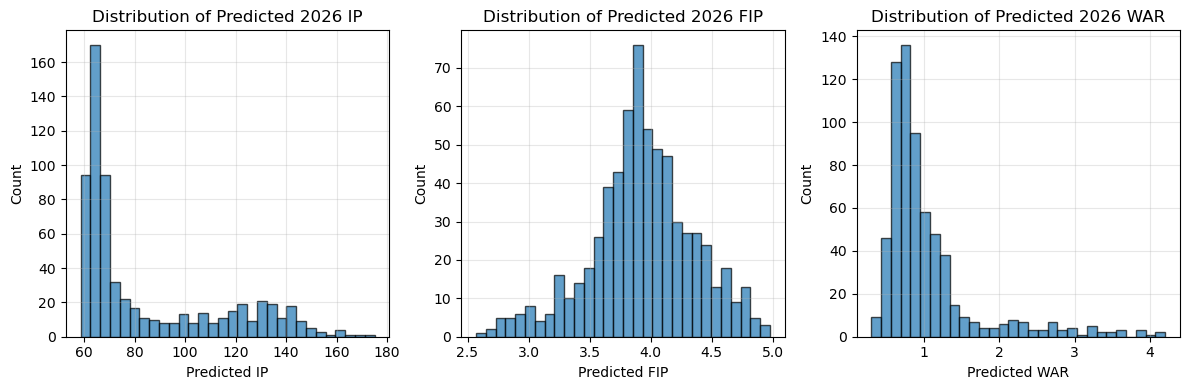

In [12]:
# Predict 2026 WAR using 2025 data
print("="*60)
print("PREDICTING 2026 WAR FOR 2025 SEASON DATA")
print("="*60)

# Prepare prediction data with scaler normalization
X_pred_np = X_pred.cpu().numpy()
num_pred_sequences, pred_seq_len, pred_num_features = X_pred_np.shape

# Reshape for scaling
X_pred_reshaped = X_pred_np.reshape(-1, pred_num_features)

# Apply the stored scaler
X_pred_scaled = scaler.transform(X_pred_reshaped)
X_pred_scaled = X_pred_scaled.reshape(num_pred_sequences, pred_seq_len, pred_num_features)
X_pred_scaled = torch.tensor(X_pred_scaled, dtype=torch.float32).to(device)

# Make predictions
model.eval()
ip_pred_2026 = []
fip_pred_2026 = []
war_pred_2026 = []

with torch.no_grad():
    for i in range(0, X_pred_scaled.shape[0], 32):  # Process in batches
        batch_end = min(i + 32, X_pred_scaled.shape[0])
        X_batch = X_pred_scaled[i:batch_end]
        ip_pred, fip_pred, war_pred = model(X_batch)
        ip_pred_2026.extend(ip_pred.cpu().numpy().flatten())
        fip_pred_2026.extend(fip_pred.cpu().numpy().flatten())
        war_pred_2026.extend(war_pred.cpu().numpy().flatten())

# Denormalize predictions
ip_pred_2026_denorm = np.array(ip_pred_2026) * y_ip_std.item() + y_ip_mean.item()
fip_pred_2026_denorm = np.array(fip_pred_2026) * y_fip_std.item() + y_fip_mean.item()
war_pred_2026_denorm = np.array(war_pred_2026) * y_war_std.item() + y_war_mean.item()

# Create results dataframe
results_df = pred_metadata_df.copy()
results_df['predicted_ip_2026'] = ip_pred_2026_denorm
results_df['predicted_fip_2026'] = fip_pred_2026_denorm
results_df['predicted_war_2026'] = war_pred_2026_denorm

# Reset index to make player_id a column for better readability
results_df = results_df.reset_index()

print(f"\n2026 Predictions for {len(results_df)} players")
print(f"\nTop 20 predicted WAR leaders for 2026:")
print(results_df.nlargest(20, 'predicted_war_2026')[['player_id', 'predicted_ip_2026', 'predicted_fip_2026', 'predicted_war_2026']])

print(f"\nPrediction Statistics:")
print(f"  Mean IP: {ip_pred_2026_denorm.mean():.2f}")
print(f"  Mean FIP: {fip_pred_2026_denorm.mean():.3f}")
print(f"  Mean WAR: {war_pred_2026_denorm.mean():.4f}")
print(f"  Min WAR: {war_pred_2026_denorm.min():.4f}")
print(f"  Max WAR: {war_pred_2026_denorm.max():.4f}")

# Save predictions to CSV
results_df.to_csv('./results/v1/2026_war_predictions.csv', index=False)
print(f"\nPredictions saved to ./results/v1/2026_war_predictions.csv")

# Plot distribution of predicted 2026 WAR
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.hist(ip_pred_2026_denorm, bins=30, edgecolor='black', alpha=0.7)
plt.xlabel('Predicted IP')
plt.ylabel('Count')
plt.title('Distribution of Predicted 2026 IP')
plt.grid(True, alpha=0.3)

plt.subplot(1, 3, 2)
plt.hist(fip_pred_2026_denorm, bins=30, edgecolor='black', alpha=0.7)
plt.xlabel('Predicted FIP')
plt.ylabel('Count')
plt.title('Distribution of Predicted 2026 FIP')
plt.grid(True, alpha=0.3)

plt.subplot(1, 3, 3)
plt.hist(war_pred_2026_denorm, bins=30, edgecolor='black', alpha=0.7)
plt.xlabel('Predicted WAR')
plt.ylabel('Count')
plt.title('Distribution of Predicted 2026 WAR')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [13]:
pd.set_option('display.max_rows', 100)
csv_path = "./results/v1/2026_war_predictions.csv"
if os.path.exists(csv_path):
    print(f"Found {csv_path}, reading into DataFrame.")
    results_df = pd.read_csv(csv_path)

data_2025 = data[data['Season'] == 2025]
results_with_name = results_df.merge(data_2025[['IDfg','Name',]], left_on=['player_id'], right_on=['IDfg'], how='left')

Found ./results/v1/2026_war_predictions.csv, reading into DataFrame.


In [14]:
results_with_name.sort_values('predicted_war_2026', ascending=False).head(100)[['Name', 'IDfg', 'predicted_war_2026',]]

,Name,IDfg,predicted_war_2026
305,Cristopher Sanchez,20778,4.205538
494,Garrett Crochet,27463,4.114755
456,Hunter Brown,25880,3.974135
640,Paul Skenes,33677,3.913930
365,Tarik Skubal,22267,3.899421
33,Chris Sale,10603,3.824729
344,Cole Ragans,21846,3.656733
199,Logan Webb,17995,3.620343
643,Yoshinobu Yamamoto,33825,3.583314
29,Zack Wheeler,10310,3.539309
